# Experiment 3: HOG (16x16) + RF (depth=None) — Traditional ML Best
**Fix:** Removed `max_depth=25` cap. Trees grow fully to separate hard classes.

**Assumes data is already downloaded** in `./data/`

In [1]:
import os, glob, yaml
import cv2
import numpy as np
from skimage.feature import hog

# ---- Load class names from YAML ----
yaml_files = glob.glob("./data/**/*.yaml", recursive=True)
with open(yaml_files[0], "r") as f:
    data_config = yaml.safe_load(f)
class_names = data_config["names"]
print(f"Classes: {len(class_names)}")

# ---- Find image and label folders ----
image_folders = []
for root, dirs, _ in os.walk("./data"):
    for d in dirs:
        if d == "images":
            image_folders.append(os.path.join(root, d))
print(f"Image folders: {image_folders}")

Classes: 38
Image folders: ['./data/PlantVillage_for_object_detection/Dataset/images']


In [2]:
# ---- Feature Extraction (HOG 16x16, NO PCA) ----

def extract_features(image):
    img_blurred = cv2.GaussianBlur(image, (5, 5), 0)
    img_resized = cv2.resize(img_blurred, (128, 128))

    b_mean, g_mean, r_mean = np.mean(img_resized, axis=(0, 1))
    b_std, g_std, r_std = np.std(img_resized, axis=(0, 1))

    gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
    hist = np.histogram(gray, bins=256)[0]
    hist = hist / np.sum(hist)

    gray_features = [
        r_mean, g_mean, b_mean,
        r_std, g_std, b_std,
        np.mean(gray), np.std(gray), np.min(gray), np.max(gray),
        np.median(gray), np.var(gray),
        -np.sum(hist * np.log2(hist + 1e-7))
    ]

    hog_features = hog(
        gray, orientations=9, pixels_per_cell=(16, 16),
        cells_per_block=(2, 2), block_norm='L2-Hys'
    )

    return np.hstack([gray_features, hog_features])


def get_class_from_label(label_path, class_names):
    if not os.path.exists(label_path):
        return None
    with open(label_path, "r") as f:
        lines = f.readlines()
    if not lines:
        return None
    class_ids = []
    for line in lines:
        parts = line.strip().split()
        if parts:
            try:
                class_ids.append(int(parts[0]))
            except ValueError:
                continue
    if not class_ids:
        return None
    most_common = max(set(class_ids), key=class_ids.count)
    if most_common < len(class_names):
        return class_names[most_common]
    return f"class_{most_common}"

print("Functions defined.")

Functions defined.


In [3]:
# ---- Load all images and extract features ----
features = []
labels = []
class_counts = {}
total_images = 0

for img_folder in image_folders:
    label_folder = img_folder.replace("images", "labels")
    if not os.path.exists(label_folder):
        continue

    print(f"Processing: {img_folder}")
    for img_file in sorted(os.listdir(img_folder)):
        if not img_file.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        img_path = os.path.join(img_folder, img_file)
        label_file = os.path.splitext(img_file)[0] + ".txt"
        label_path = os.path.join(label_folder, label_file)

        cls = get_class_from_label(label_path, class_names)
        if cls is None:
            continue

        image = cv2.imread(img_path)
        if image is None:
            continue

        feat = extract_features(image)
        features.append(feat)
        labels.append(cls)
        class_counts[cls] = class_counts.get(cls, 0) + 1
        total_images += 1
        if total_images % 5000 == 0:
            print(f"  {total_images} images processed...")

X, y = np.array(features), np.array(labels)
print(f"\nTotal samples: {len(X)}, Features per sample: {X.shape[1]}")

Processing: ./data/PlantVillage_for_object_detection/Dataset/images
  5000 images processed...
  10000 images processed...
  15000 images processed...
  20000 images processed...
  25000 images processed...
  30000 images processed...
  35000 images processed...
  40000 images processed...
  45000 images processed...
  50000 images processed...

Total samples: 54293, Features per sample: 1777


In [4]:
# ---- Train/Test Split (NO PCA, NO Scaler) ----
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Train: 43434, Test: 10859


In [5]:
# ---- Train Random Forest (max_depth=None — UNLIMITED) ----
from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest (500 trees, max_depth=None, balanced)...")
model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Training done.")

Training Random Forest (500 trees, max_depth=None, balanced)...
Training done.


In [6]:
# ---- Results ----
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

accuracy = accuracy_score(y_test, y_pred)
print(f"\n{'='*50}")
print(f"  ACCURACY: {accuracy:.2%}")
print(f"{'='*50}")

report = classification_report(y_test, y_pred)
print(f"\nClassification Report:\n")
print(report)

with open("classification_report_best.txt", "w") as f:
    f.write(f"Accuracy: {accuracy:.2%}\n\n")
    f.write(f"Dataset: PlantVillage YOLO | Samples: {len(X)}\n")
    f.write(f"Features: {X.shape[1]} (HOG 16x16, no PCA) | max_depth=None\n")
    f.write(f"Train: {len(X_train)}, Test: {len(X_test)}\n\n")
    f.write(report)
print("Saved classification_report_best.txt")


  ACCURACY: 75.31%

Classification Report:

                                               precision    recall  f1-score   support

                           Apple___Apple_scab       0.70      0.06      0.10       126
                            Apple___Black_rot       0.82      0.81      0.81       124
                     Apple___Cedar_apple_rust       0.00      0.00      0.00        55
                              Apple___healthy       0.65      0.41      0.50       329
                          Blueberry___healthy       0.74      0.86      0.80       300
                      Cherry___Powdery_mildew       0.91      0.73      0.81       210
                             Cherry___healthy       0.92      0.85      0.88       171
   Corn___Cercospora_leaf_spot Gray_leaf_spot       0.85      0.34      0.49       103
                           Corn___Common_rust       0.97      0.99      0.98       238
                  Corn___Northern_Leaf_Blight       0.65      0.81      0.72       1

/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


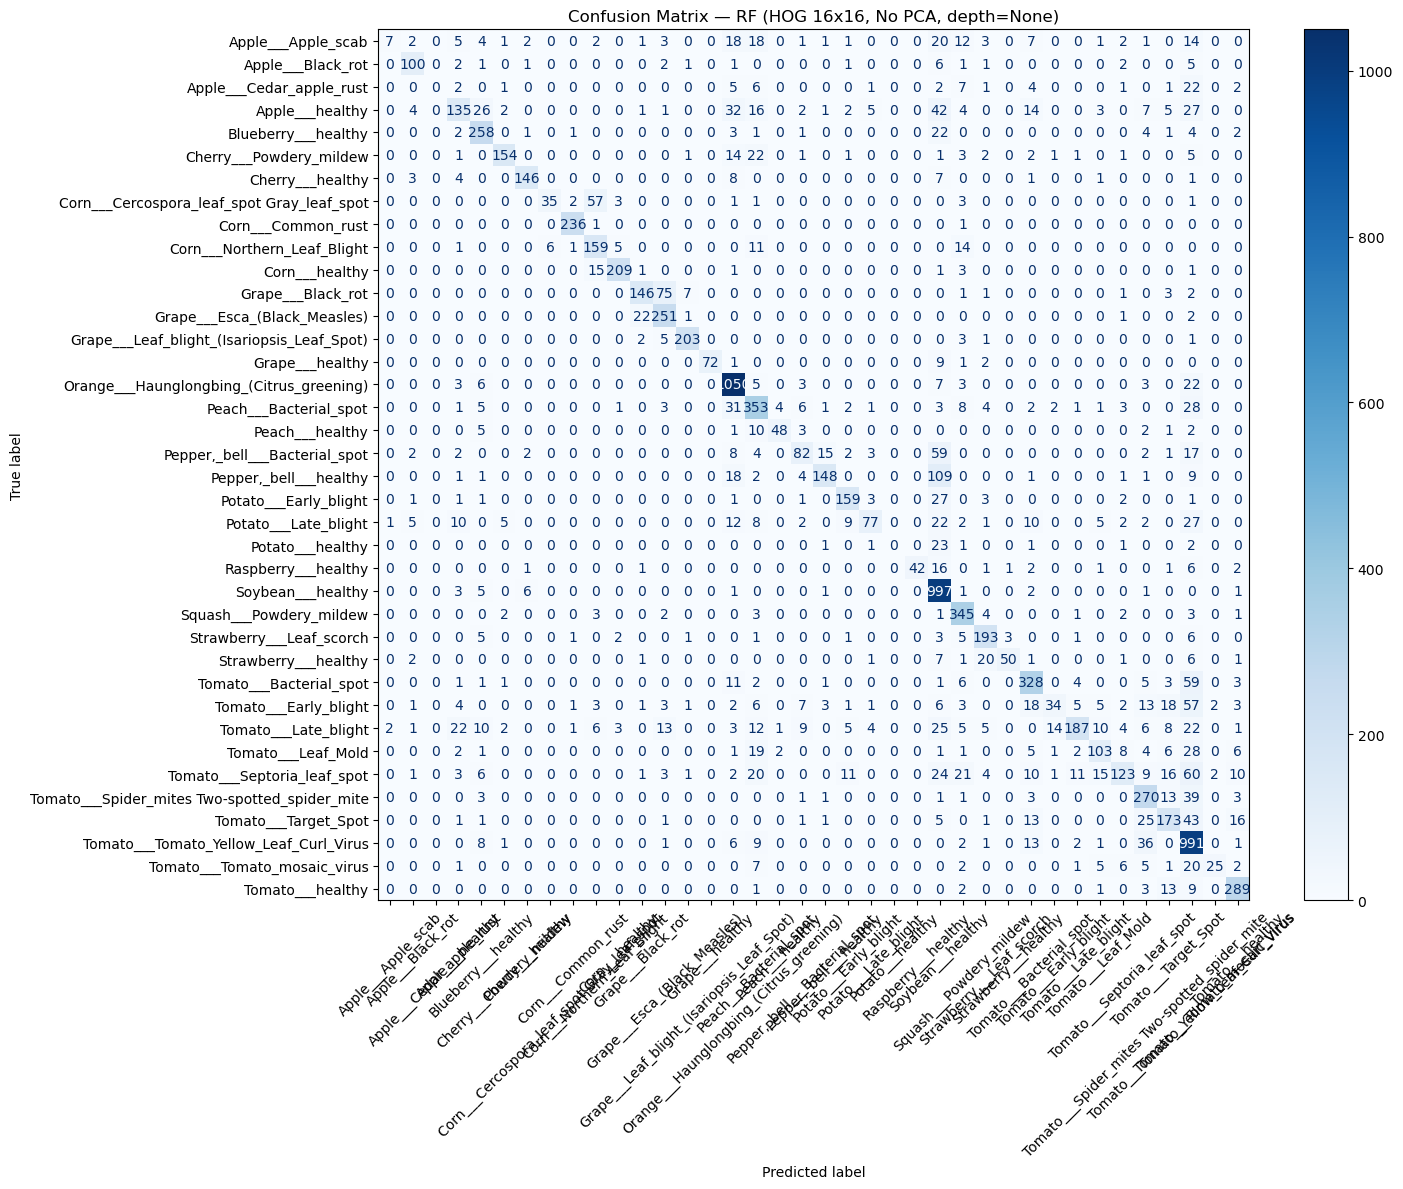

Saved confusion_matrix_best.png


In [7]:
# ---- Confusion Matrix ----
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
fig, ax = plt.subplots(figsize=(15, 12))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix — RF (HOG 16x16, No PCA, depth=None)")
plt.tight_layout()
plt.savefig("confusion_matrix_best.png", dpi=150)
plt.show()
print("Saved confusion_matrix_best.png")

In [8]:
# ---- Save pipeline ----
import joblib

model.n_jobs = 1
pipeline = {"model": model, "classes": model.classes_}

joblib.dump(pipeline, "leaf_disease_pipeline_best.pkl", compress=3)
size_mb = os.path.getsize("leaf_disease_pipeline_best.pkl") / (1024 * 1024)
print(f"Saved leaf_disease_pipeline_best.pkl ({size_mb:.1f} MB)")

Saved leaf_disease_pipeline_best.pkl (511.1 MB)


In [9]:
print("DONE! Output files:")
print("  confusion_matrix_best.png")
print("  classification_report_best.txt")
print("  leaf_disease_pipeline_best.pkl")

DONE! Output files:
  confusion_matrix_best.png
  classification_report_best.txt
  leaf_disease_pipeline_best.pkl
